# 🎯 YOLOv8 Training for P&ID Symbol Detection

**Train a custom YOLOv8 model to detect engineering symbols in P&ID drawings.**

This notebook is designed to run on **Google Colab (free T4 GPU)**.

## Dataset Options
- **Option A (Recommended):** Roboflow "P&ID Object Detection AI Ready" (7.1k+ images, YOLOv8 format)
- **Option B:** Hugging Face "Digitize-PID" (500 synthetic P&IDs, YOLO format)

## Steps
1. Install dependencies
2. Download dataset
3. Explore the dataset
4. Train YOLOv8s model
5. Evaluate and export weights
6. Download `best.pt` to your laptop

## Step 1: Install Dependencies

In [1]:
!pip install ultralytics roboflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.3/45.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 35.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 276.9/276.9 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 142.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 5.5 MB/s eta 0:00:00


## Step 2: Download Dataset

### Option A — Roboflow (Recommended, larger dataset)

1. Go to https://universe.roboflow.com/ai-ready-program/p-id-object-detection-ai-ready-pomcl
2. Click **"Download Dataset"** → Select **YOLOv8** format
3. Copy the download code snippet (you'll need a free Roboflow account)

Or use the code below after getting your API key from Roboflow:

In [2]:
# ============================================================
# OPTION A: Roboflow Dataset (Recommended)
# ============================================================
# Get your free API key from: https://app.roboflow.com/settings/api
# Then uncomment and run:

from roboflow import Roboflow
rf = Roboflow(api_key="jhHGRzKwaexFJ3T6oEdA")
project = rf.workspace("ai-ready-program").project("p-id-object-detection-ai-ready-pomcl")
version = project.version(1)
dataset = version.download("yolov8", location="/content/dataset")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to /content/dataset in yolov8:: 100%|██████████| 14244/14244 [00:02<00:00, 5589.56it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
# ============================================================
# OPTION B: Hugging Face Digitize-PID Dataset (No API key needed)
# ============================================================
# This is a 500-image synthetic P&ID dataset in YOLO format

# !pip install huggingface_hub -q

# from huggingface_hub import snapshot_download
# import os

# # Download the dataset
# dataset_path = snapshot_download(
#     repo_id="hamzas/digitize-pid-yolo",
#     repo_type="dataset",
#     local_dir="/content/dataset"
# )

# print(f"Dataset downloaded to: {dataset_path}")
# !ls /content/dataset/

## Step 3: Explore the Dataset

In [4]:
import yaml
from pathlib import Path
import matplotlib.pyplot as plt
import cv2
import numpy as np
import glob

# Find the data.yaml file
yaml_files = glob.glob('/content/dataset/**/data.yaml', recursive=True)
if not yaml_files:
    yaml_files = glob.glob('/content/dataset/**/*.yaml', recursive=True)

print("Found YAML files:", yaml_files)
data_yaml_path = yaml_files[0] if yaml_files else None

if data_yaml_path:
    with open(data_yaml_path, 'r') as f:
        data_config = yaml.safe_load(f)

    print(f"\nNumber of classes: {data_config.get('nc', len(data_config.get('names', [])))}")
    print(f"\nClass names (first 20):")
    names = data_config.get('names', [])
    if isinstance(names, dict):
        names = list(names.values())
    for i, name in enumerate(names[:20]):
        print(f"  {i}: {name}")
    if len(names) > 20:
        print(f"  ... and {len(names) - 20} more")
else:
    print("No data.yaml found. Listing directory contents:")
    !find /content/dataset -type f | head -30

Found YAML files: ['/content/dataset/data.yaml']

Number of classes: 229

Class names (first 20):
  0: 3 Way Ball Valve
  1: 3 Way Gate Valve
  2: 3 Way Globe Valve
  3: 3 Way Valve
  4: 4 Way Ball Valve
  5: 4 Way Gate Valve
  6: 4 Way Valve
  7: Agitator or Mixer
  8: Alkyalation
  9: Angle Blowdown
  10: Angle GlobeValve
  11: Angle Valve
  12: Automatic Stoker
  13: Axial Compressor
  14: Axical COMP
  15: Back Pressure Regulator
  16: BackPressure Regulator
  17: Balance Diaphragm Gate Valve
  18: Ball_valve
  19: Bleeder Valve
  ... and 209 more


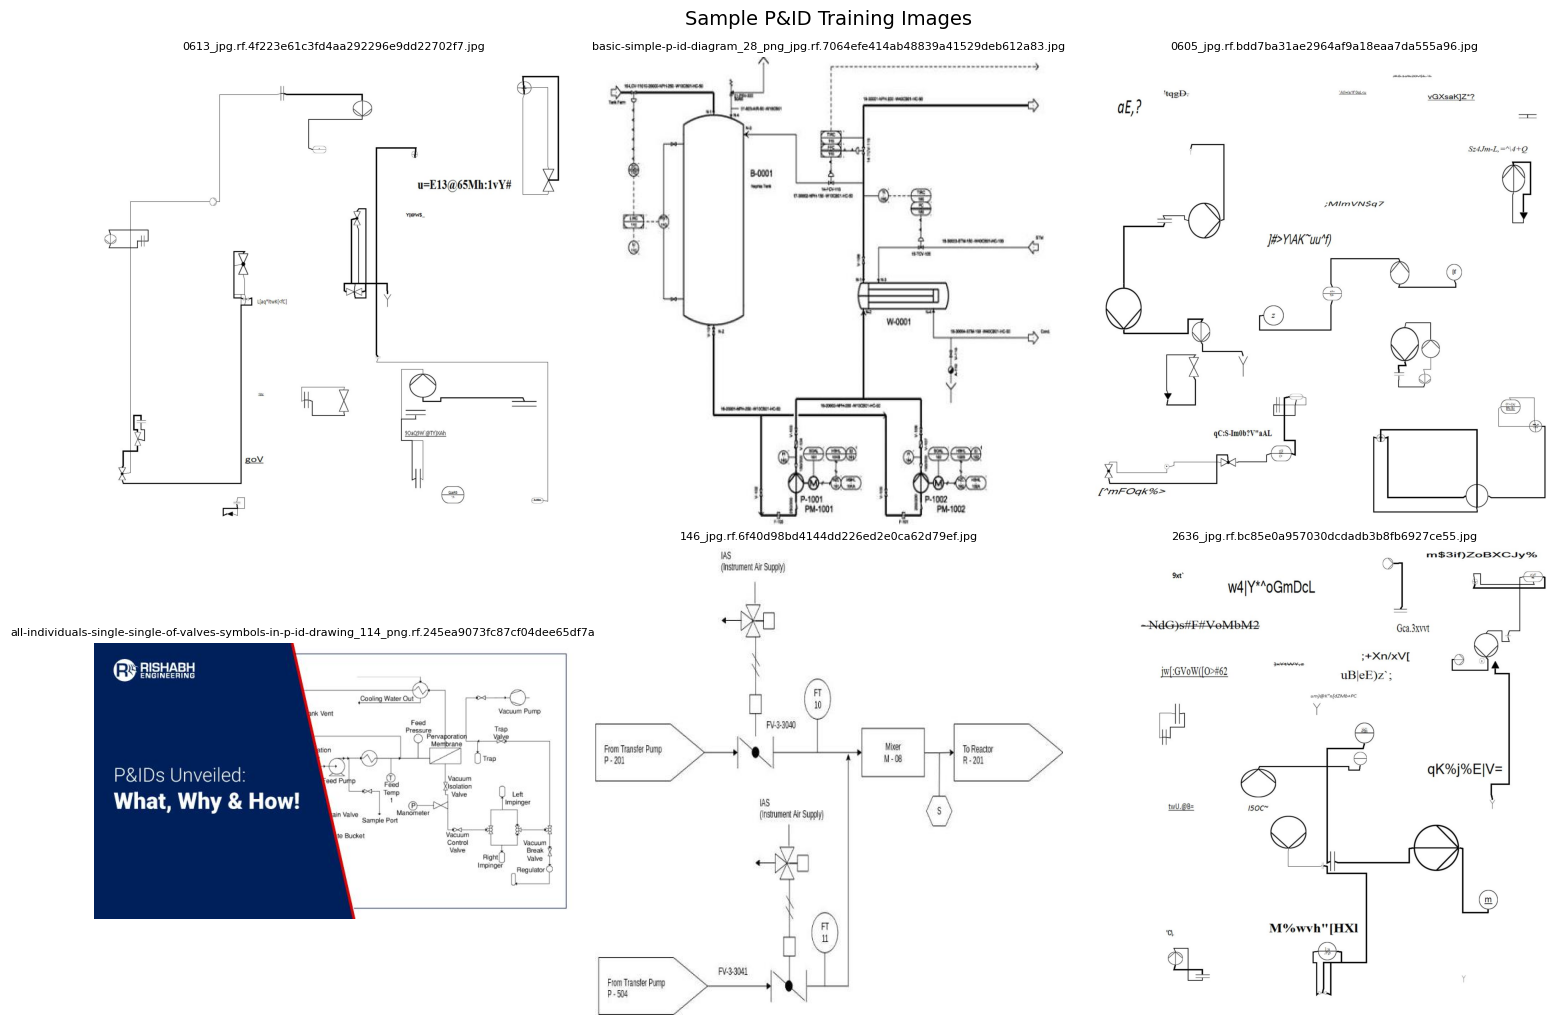

In [5]:
# Visualize sample images
train_dirs = glob.glob('/content/dataset/**/train/images', recursive=True)
if not train_dirs:
    train_dirs = glob.glob('/content/dataset/**/images/train', recursive=True)
if not train_dirs:
    train_dirs = glob.glob('/content/dataset/**/images', recursive=True)

if train_dirs:
    train_imgs_dir = Path(train_dirs[0])
    sample_images = list(train_imgs_dir.glob('*.png')) + list(train_imgs_dir.glob('*.jpg'))
    sample_images = sample_images[:6]

    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    for ax, img_path in zip(axes.flatten(), sample_images):
        img = cv2.imread(str(img_path))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        ax.imshow(img)
        ax.set_title(img_path.name, fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.suptitle('Sample P&ID Training Images', fontsize=14, y=1.02)
    plt.show()
else:
    print("Could not find training images directory")
    !find /content/dataset -type d

## Step 4: Fix data.yaml Paths for Colab

The data.yaml paths may reference the original author's machine. We need to update them.

In [6]:
import os

# Auto-detect dataset structure
dataset_root = '/content/dataset'

# Find train/val/test directories
def find_split_dir(root, split_name):
    """Find the images directory for a given split."""
    patterns = [
        f'{split_name}/images',
        f'images/{split_name}',
        f'{split_name}',
    ]
    for pattern in patterns:
        candidates = glob.glob(f'{root}/**/{pattern}', recursive=True)
        if candidates:
            return candidates[0]
    return None

train_path = find_split_dir(dataset_root, 'train')
val_path = find_split_dir(dataset_root, 'valid') or find_split_dir(dataset_root, 'val')
test_path = find_split_dir(dataset_root, 'test')

print(f"Train: {train_path}")
print(f"Val:   {val_path}")
print(f"Test:  {test_path}")

# Update data.yaml
if data_yaml_path and train_path:
    data_config['train'] = train_path
    data_config['val'] = val_path or train_path  # fallback to train if no val
    if test_path:
        data_config['test'] = test_path

    # Ensure 'nc' is set
    names = data_config.get('names', [])
    if isinstance(names, dict):
        data_config['nc'] = len(names)
    elif isinstance(names, list):
        data_config['nc'] = len(names)

    updated_yaml_path = '/content/pid_data.yaml'
    with open(updated_yaml_path, 'w') as f:
        yaml.dump(data_config, f, default_flow_style=False)

    print(f"\nUpdated data.yaml saved to: {updated_yaml_path}")
    print(f"Classes: {data_config['nc']}")
else:
    print("ERROR: Could not auto-configure. Please set paths manually.")

Train: /content/dataset/train/images
Val:   /content/dataset/valid/images
Test:  /content/dataset/test/images

Updated data.yaml saved to: /content/pid_data.yaml
Classes: 229


## Step 5: Train YOLOv8s Model

Using YOLOv8s (small) — best accuracy/speed tradeoff for CPU inference on your laptop.

In [7]:
from ultralytics import YOLO

# Load pre-trained YOLOv8s
model = YOLO('yolov8s.pt')

# Train on P&ID dataset
results = model.train(
    data=updated_yaml_path,
    epochs=100,
    imgsz=640,
    batch=16,
    device=0,  # GPU
    project='/content/runs',
    name='pid_yolov8s',
    patience=15,           # Early stopping
    save=True,
    plots=True,
    # Augmentation for engineering drawings
    hsv_h=0.01,           # Minimal color augmentation (drawings are B&W)
    hsv_s=0.1,
    hsv_v=0.2,
    degrees=5,            # Slight rotation
    translate=0.1,
    scale=0.3,
    flipud=0.0,           # No vertical flip (symbols have orientation)
    fliplr=0.0,           # No horizontal flip
    mosaic=0.5,
)

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/pid_data.yaml, degrees=5, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.0, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.01, hsv_s=0.1, hsv_v=0.2, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=0.5, multi_scale=0.0, name=pid_yolov8s, nbs=64, nms=False, opset=None, optimize=False, o

## Step 6: Evaluate Model

In [8]:
# Validate on test/val set
val_split = 'test' if test_path else 'val'
metrics = model.val(
    data=updated_yaml_path,
    split=val_split,
    imgsz=640,
)

print(f"\n{'='*50}")
print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")
print(f"{'='*50}")

Ultralytics 8.4.104 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 11,214,207 parameters, 0 gradients, 28.9 GFLOPs
WARNING ⚠️ val: Slow image access detected (ping: 0.0±0.0 ms, read: 17.0±14.7 MB/s, size: 47.9 KB). Use local storage instead of remote/mounted storage for better performance. See https://docs.ultralytics.com/guides/model-training-tips/
val: Scanning /content/dataset/test/labels... 711 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 711/711 693.2it/s 1.0s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 45/45 3.2it/s 13.9s
                   all        711      12388       0.84      0.814      0.851      0.659
      3 Way Ball Valve          5          6      0.681      0.833      0.881      0.655
      3 Way Gate Valve         52         69      0.902      0.812      0.813      0.611
     3 Way Globe V

In [ ]:
# Visualize training curves
from IPython.display import Image, display

results_img = '/content/runs/pid_yolov8s/results.png'
if os.path.exists(results_img):
    display(Image(filename=results_img, width=800))

conf_matrix = '/content/runs/pid_yolov8s/confusion_matrix.png'
if os.path.exists(conf_matrix):
    display(Image(filename=conf_matrix, width=600))


image 1/1 /content/dataset/test/images/1101_jpg.rf.94f3d9c6c47121b65dcb21f712310e8b.jpg: 640x640 6 FlangePairs, 5 Funnels, 7 Indicators, 8 Pumps, 7 Valves, 16.4ms
Speed: 6.2ms preprocess, 16.4ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/pid_predictions


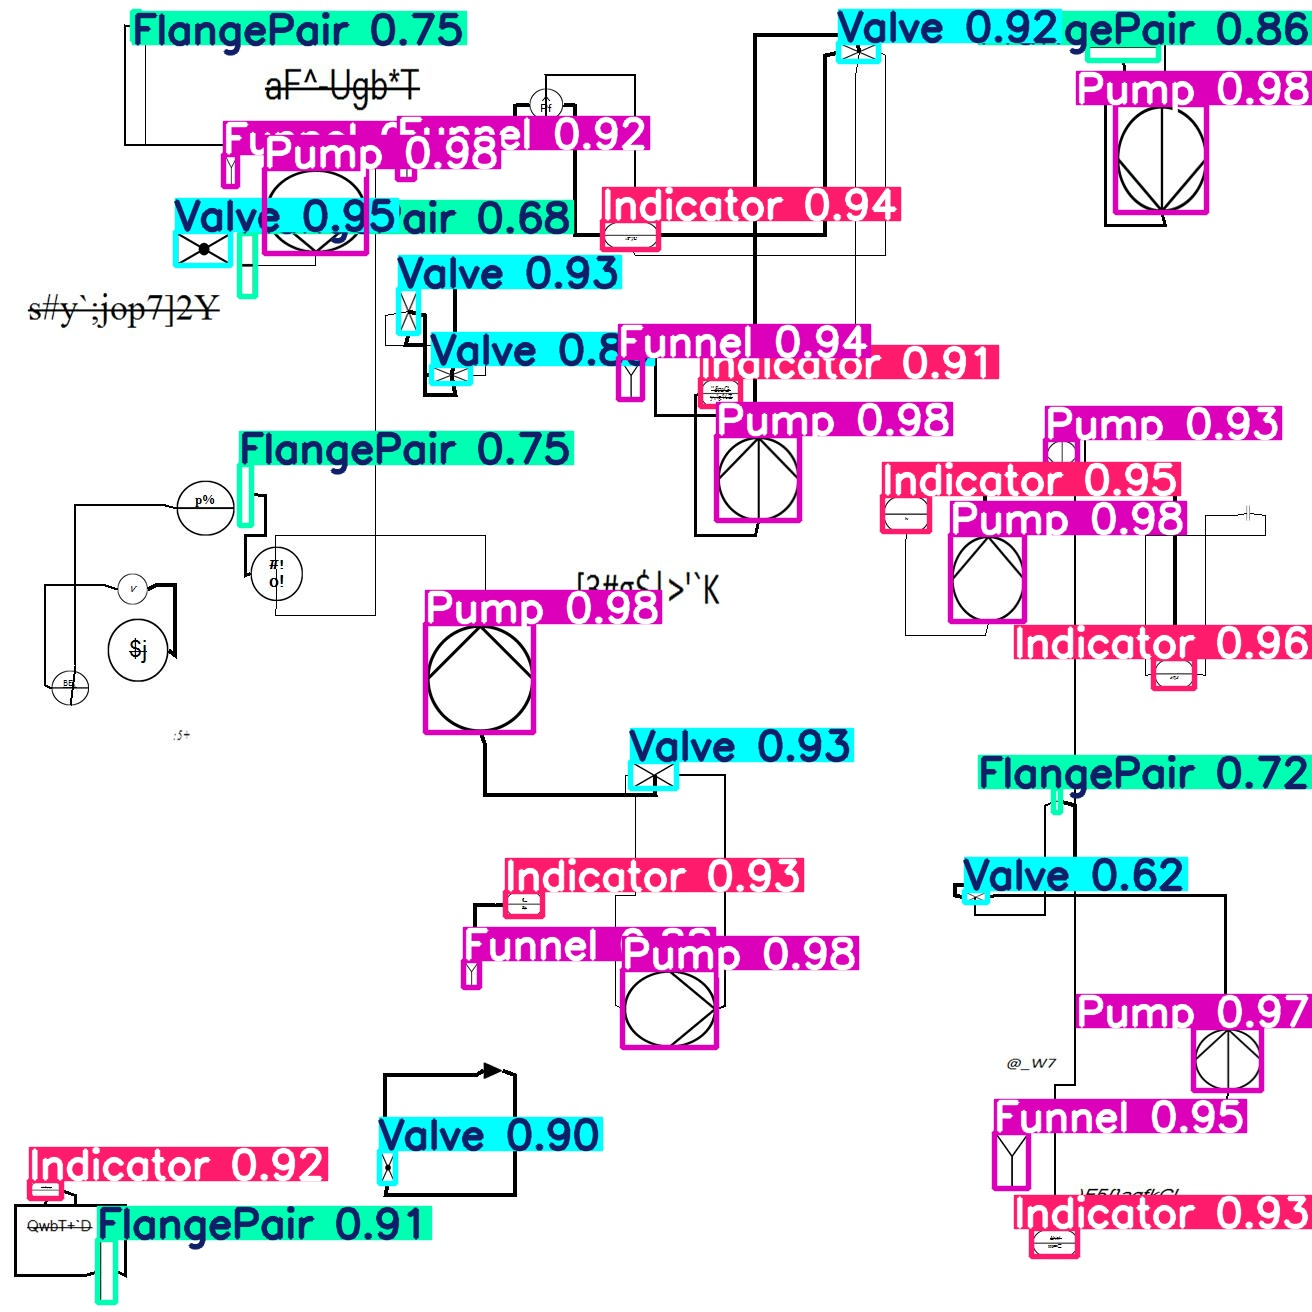


1101_jpg.rf.94f3d9c6c47121b65dcb21f712310e8b.jpg: 33 detections

image 1/1 /content/dataset/test/images/2466_jpg.rf.008d06673dd204acc2b43ad2bcae17bf.jpg: 640x640 5 FlangePairs, 2 Funnels, 6 Indicators, 7 Pumps, 7 Valves, 16.4ms
Speed: 5.5ms preprocess, 16.4ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/pid_predictions


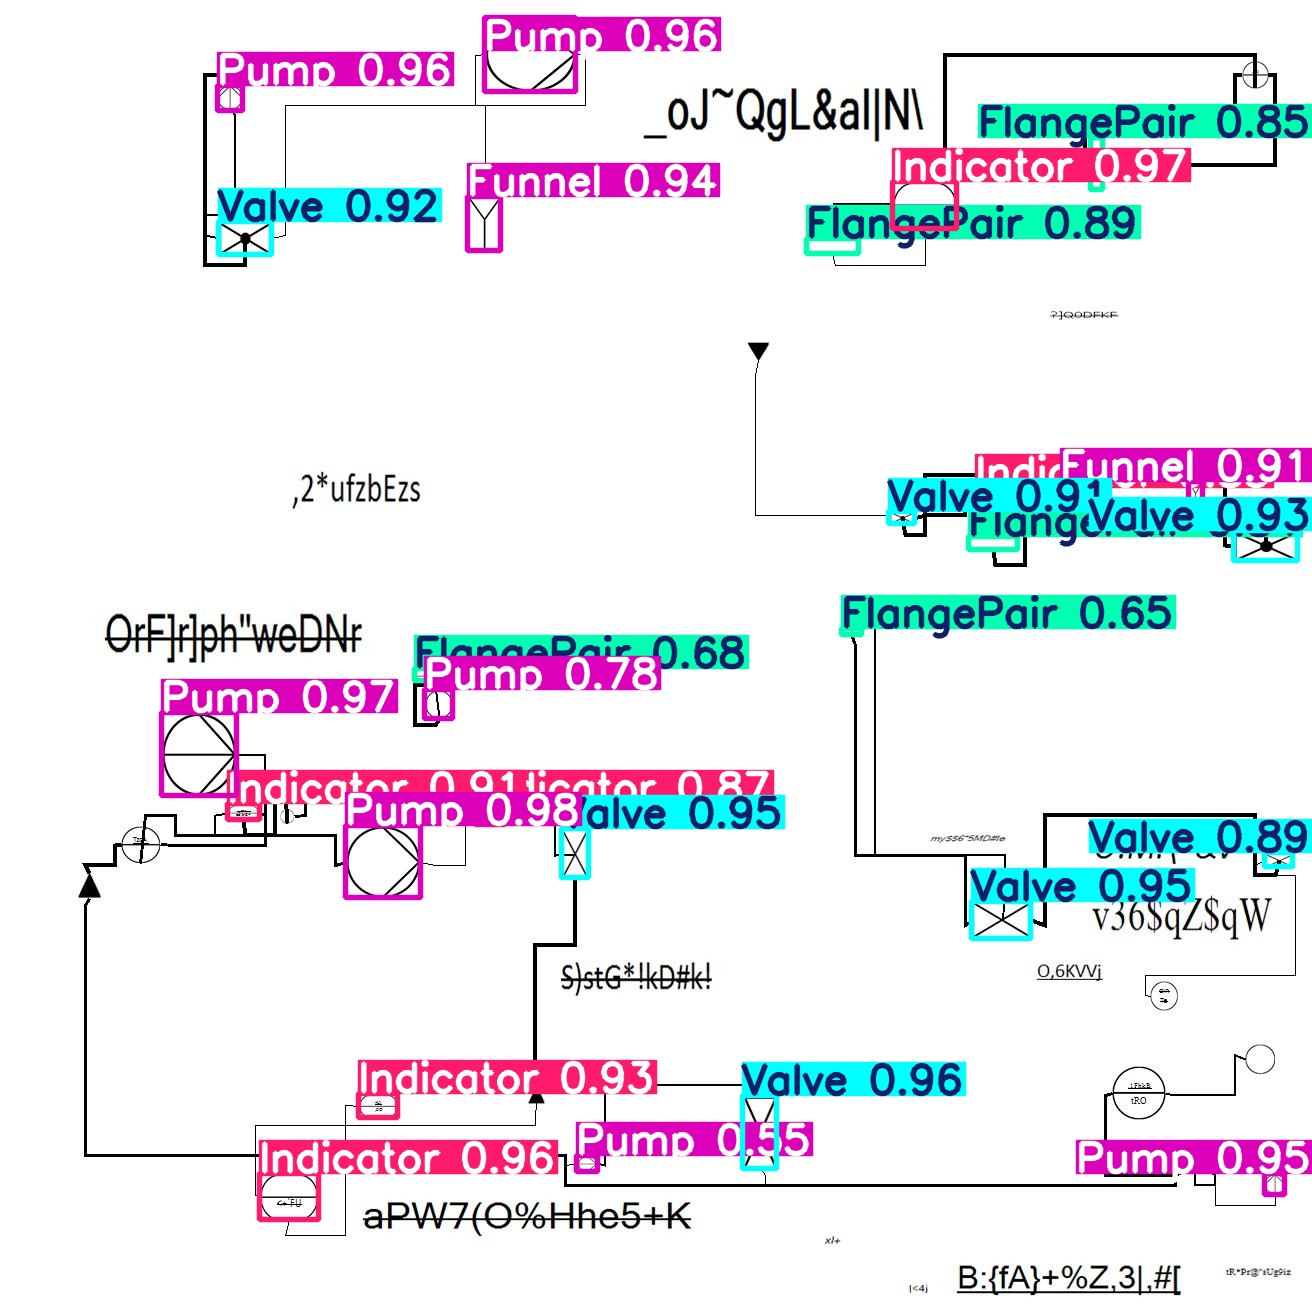


2466_jpg.rf.008d06673dd204acc2b43ad2bcae17bf.jpg: 27 detections

image 1/1 /content/dataset/test/images/2005_jpg.rf.4e9e79d46e791269d61a04c13d8b3bee.jpg: 640x640 7 FlangePairs, 1 Funnel, 7 Indicators, 7 Pumps, 4 Valves, 17.7ms
Speed: 7.8ms preprocess, 17.7ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/pid_predictions


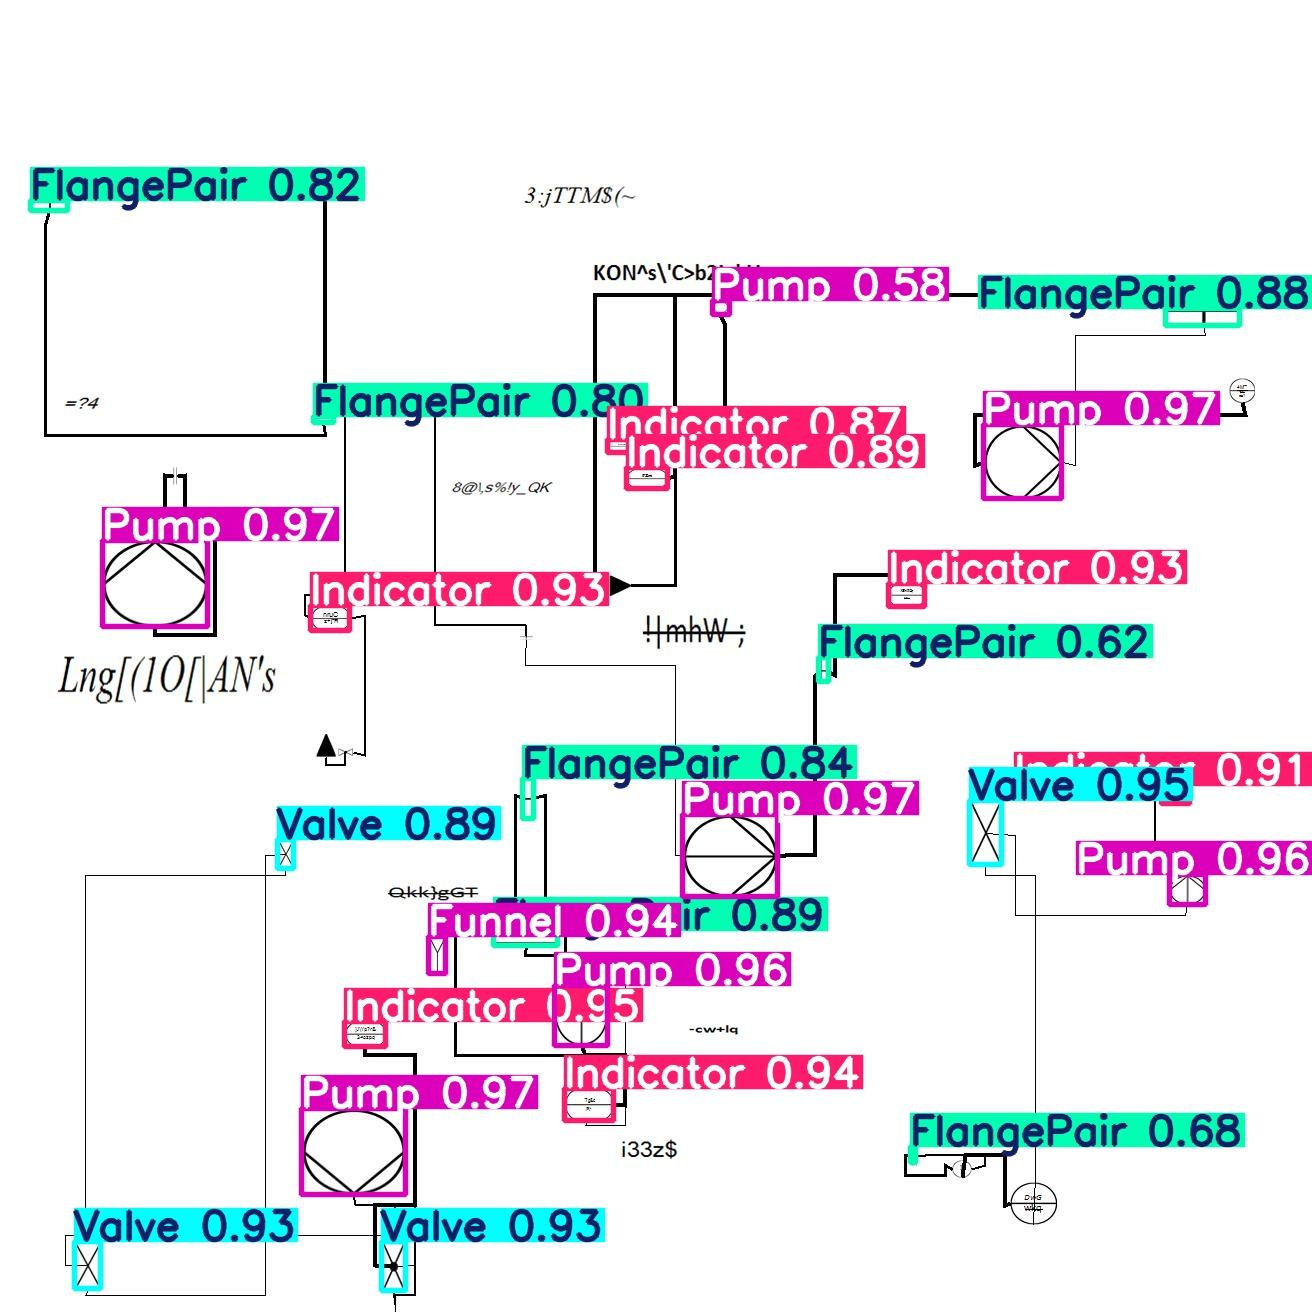


2005_jpg.rf.4e9e79d46e791269d61a04c13d8b3bee.jpg: 26 detections

image 1/1 /content/dataset/test/images/1634_jpg.rf.8c5d5dcb22dba4208d97de08713dc536.jpg: 640x640 8 FlangePairs, 4 Funnels, 8 Indicators, 10 Pumps, 3 Valves, 16.4ms
Speed: 5.5ms preprocess, 16.4ms inference, 1.8ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/pid_predictions


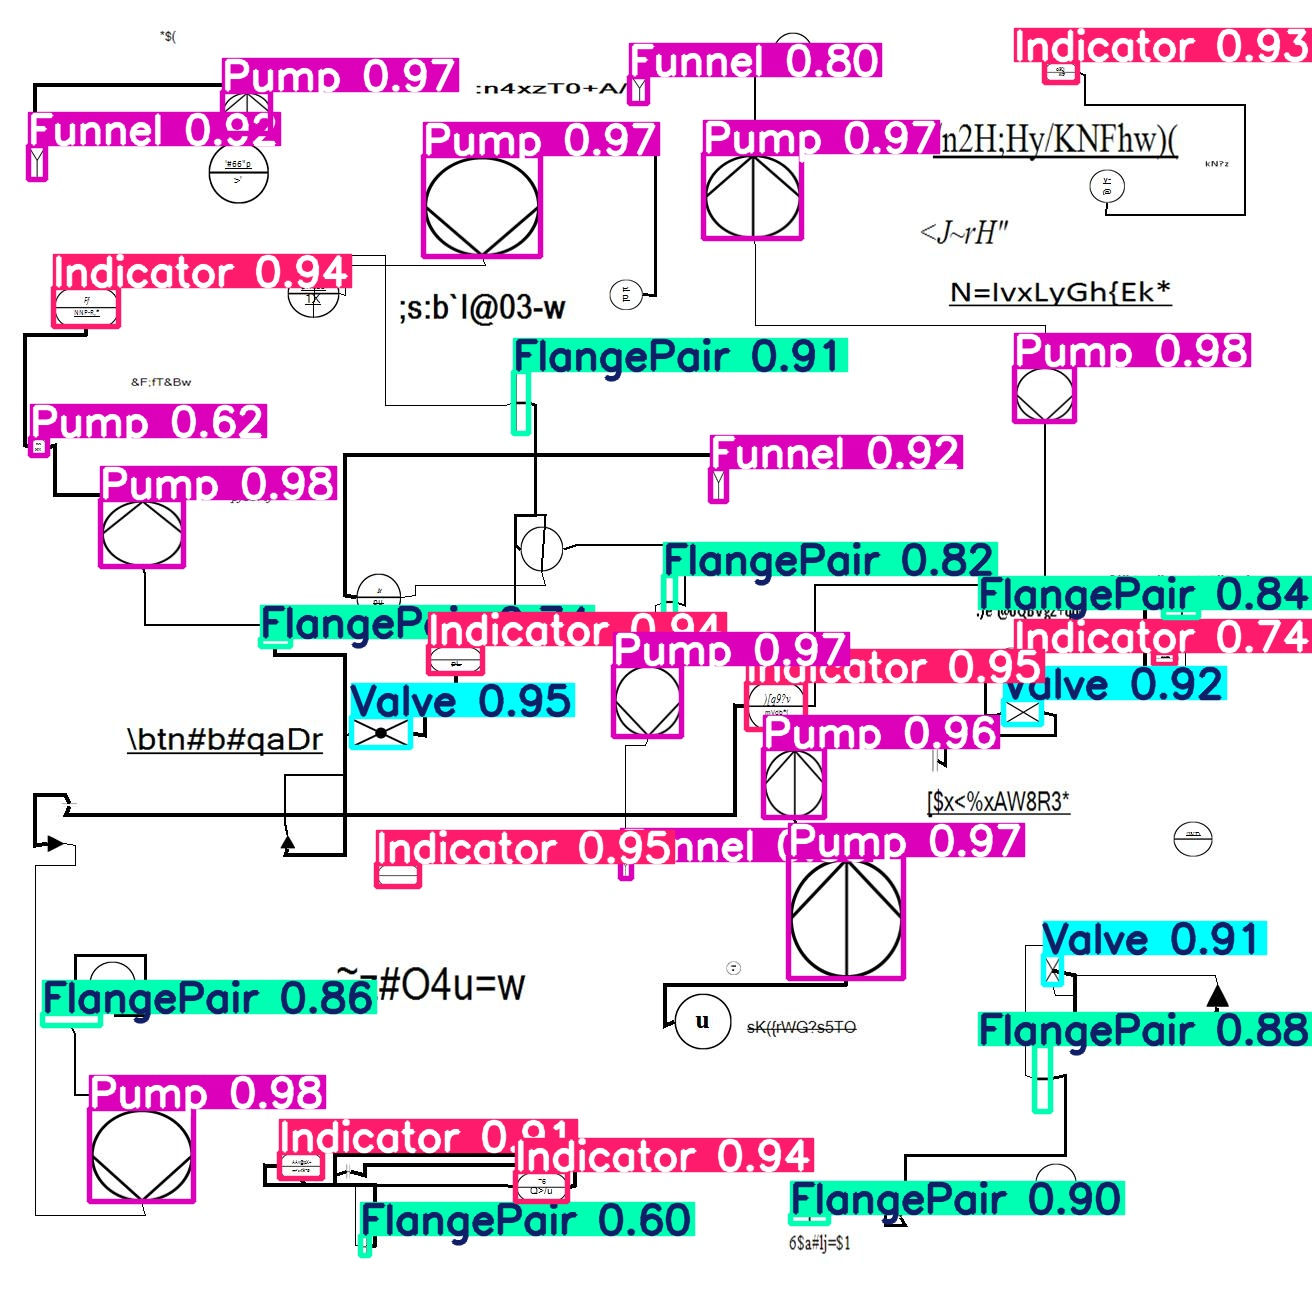


1634_jpg.rf.8c5d5dcb22dba4208d97de08713dc536.jpg: 33 detections


In [10]:
# Test inference on sample images
test_dir = test_path or val_path or train_path
test_imgs = list(Path(test_dir).glob('*.png')) + list(Path(test_dir).glob('*.jpg'))
test_imgs = test_imgs[:4]

for img_path in test_imgs:
    results = model.predict(
        source=str(img_path),
        conf=0.5,
        save=True,
        project='/content/runs',
        name='pid_predictions',
        exist_ok=True,
    )

    pred_img_path = f'/content/runs/pid_predictions/{img_path.name}'
    if os.path.exists(pred_img_path):
        display(Image(filename=pred_img_path, width=600))

    for result in results:
        print(f"\n{img_path.name}: {len(result.boxes)} detections")

## Step 7: Export & Download Trained Weights

In [11]:
import os

# Path to best weights
best_weights = '/content/runs/pid_yolov8s/weights/best.pt'
print(f"Best weights: {best_weights}")
print(f"File size: {os.path.getsize(best_weights) / 1024 / 1024:.1f} MB")

# Download to your laptop
from google.colab import files
files.download(best_weights)

Best weights: /content/runs/pid_yolov8s/weights/best.pt
File size: 21.6 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 📋 Next Steps

1. **Download** `best.pt` to your laptop
2. **Move** it to `models/best.pt` in your project directory
3. **Run** the full pipeline: `streamlit run app/streamlit_app.py`

The pipeline will automatically detect and use your trained model!

### Dataset Sources Used
- **Roboflow:** https://universe.roboflow.com/ai-ready-program/p-id-object-detection-ai-ready-pomcl
- **Hugging Face:** https://huggingface.co/datasets/hamzas/digitize-pid-yolo
- **Paper:** Paliwal et al. (2021) "Digitize-PID: Automatic Digitization of P&IDs" (arXiv:2109.03794)